In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("credit_card_fraud.csv")

# Basic info
print(df.head())
print(df.info())
print(df['is_fraud'].value_counts())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [8]:
df.shape

(10000, 10)

In [9]:
df = df.drop(['transaction_id'], axis=1, errors='ignore')

In [10]:
df = pd.get_dummies(df)

In [11]:
x = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [12]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
x_scaled = sc.fit_transform(x)

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [15]:
x_train_normal = x_train[y_train == 0]

In [16]:
x_train_normal.shape

(7880, 12)

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = x_train.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dense(8, activation='relu')(encoded)  # bottleneck

# Decoder
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

In [18]:
autoencoder.compile(optimizer='adam',loss='mse')

In [19]:
history = autoencoder.fit(
    x_train_normal,
    x_train_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1207 - val_loss: 0.0844
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0718 - val_loss: 0.0525
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0412 - val_loss: 0.0373
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0338 - val_loss: 0.0318
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0296 - val_loss: 0.0278
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0240 - val_loss: 0.0210
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0203 - val_loss: 0.0194
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0191 - val_loss: 0.0186
Epoch 9/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0184 - val_loss: 0.0179
Epoch 10/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - val_loss: 0.0175
Epoch 11/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0175 - val_loss: 0.0172
Epoch 12/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

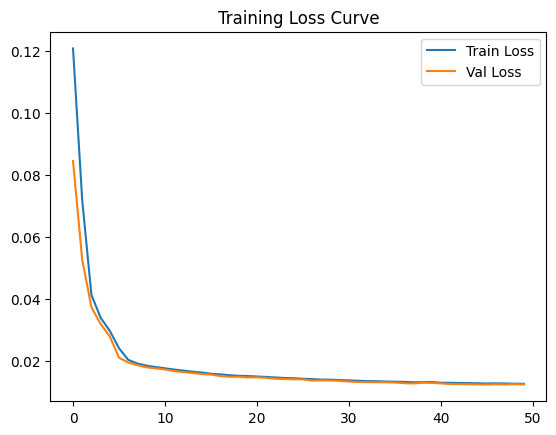

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training Loss Curve")
plt.show()

In [25]:
x_test_pred = autoencoder.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [26]:
mse = np.mean(np.power(x_test - x_test_pred, 2), axis=1)

In [27]:
threshold = np.percentile(mse, 95)
print("Threshold:", threshold)

Threshold: 0.04472797281162546


In [28]:
y_pred = (mse > threshold).astype(int)

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1969
           1       0.10      0.32      0.15        31

    accuracy                           0.94      2000
   macro avg       0.54      0.64      0.56      2000
weighted avg       0.98      0.94      0.96      2000



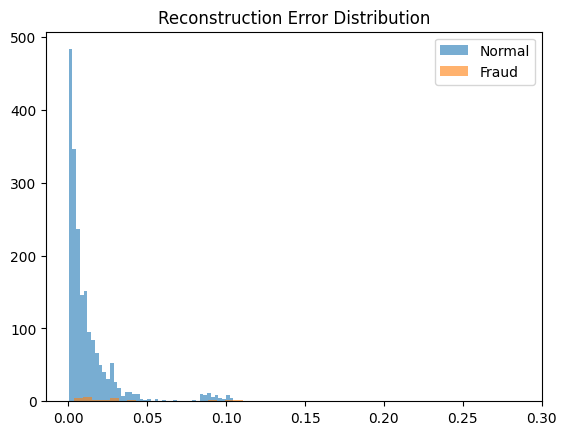

In [31]:
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label='Normal')
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

In [32]:
fraud_scores = pd.DataFrame({
    'error': mse,
    'actual': y_test
})

top10 = fraud_scores.sort_values(by='error', ascending=False).head(10)
print(top10)

         error  actual
6953  0.286001       1
9587  0.232715       1
5768  0.118754       0
3383  0.116031       0
9834  0.110416       0
617   0.109518       1
3706  0.109502       1
2523  0.104655       0
3210  0.103631       0
6001  0.103281       1
